In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

In [8]:
pattern = r"(\w+)_cells(\d+)_features(\d+)_([a-z1-9]+)_(\w+)_seed(\d+)_log"
optimal_df = pd.read_csv("ground_truths.csv")
skargs = dict(header=None, skipfooter=1, 
                      names=[
    "time(s)", "iter", "infeas", "ot_objective", "dual", "solver"
])
def load_df(path, **kwargs):
    dataset, ncells, nfeatures, metric, solver, seed = re.findall(pattern, path)[0]
    ncells, nfeatures, seed = map(int, [ncells, nfeatures, seed])
    
    if "sinkhorn" in path and "annealed" not in path:
        df = pd.read_csv(path, **skargs).iloc[1:]
    else:
        df = pd.read_csv(path, skipfooter=1)
    df['seed'] = seed; df['ncells'] = ncells; df["nfeatures"] = nfeatures; df['metric'] = metric
    df = df.merge(optimal_df, on=["metric", "seed", "nfeatures", "ncells"])
    df["compound_obj"] = np.abs(df["ot_objective"].astype(float) - df['cost']) + df["infeas"].astype(float)
    df["time(s)"] = df["time(s)"].astype(float)
    return df
flist = glob("*seed*_log.csv")
dflist = []
for f in tqdm(flist):
    df = load_df(f)
    dflist.append(df)


100%|██████████| 230/230 [00:53<00:00,  4.34it/s]


In [11]:
df = pd.concat(dflist).reset_index(drop=True)

In [81]:
arr = np.exp(pd.cut(np.log(df['time(s)']), bins=200 , precision=2,retbins=True)[0].apply(lambda x: x.mid).to_numpy())
# np.exp(arr[0].iloc[0].mid)
df['bintime'] = arr
df['Algorithm'] = df['solver'].replace({"lamp_kernel": "LAMP", 
                                        "annealed_sinkhorn_cellsim": "MDOT-SK",
                                        "sinkhorn_cellsim": "SK"})
df["Metric"] = df['metric'].replace({
    "l1": "$\\ell_1$", 
    "l2": "$\\ell_2$",
    "correlation": "Correlation", 
    "cosine": "Cosine"
})

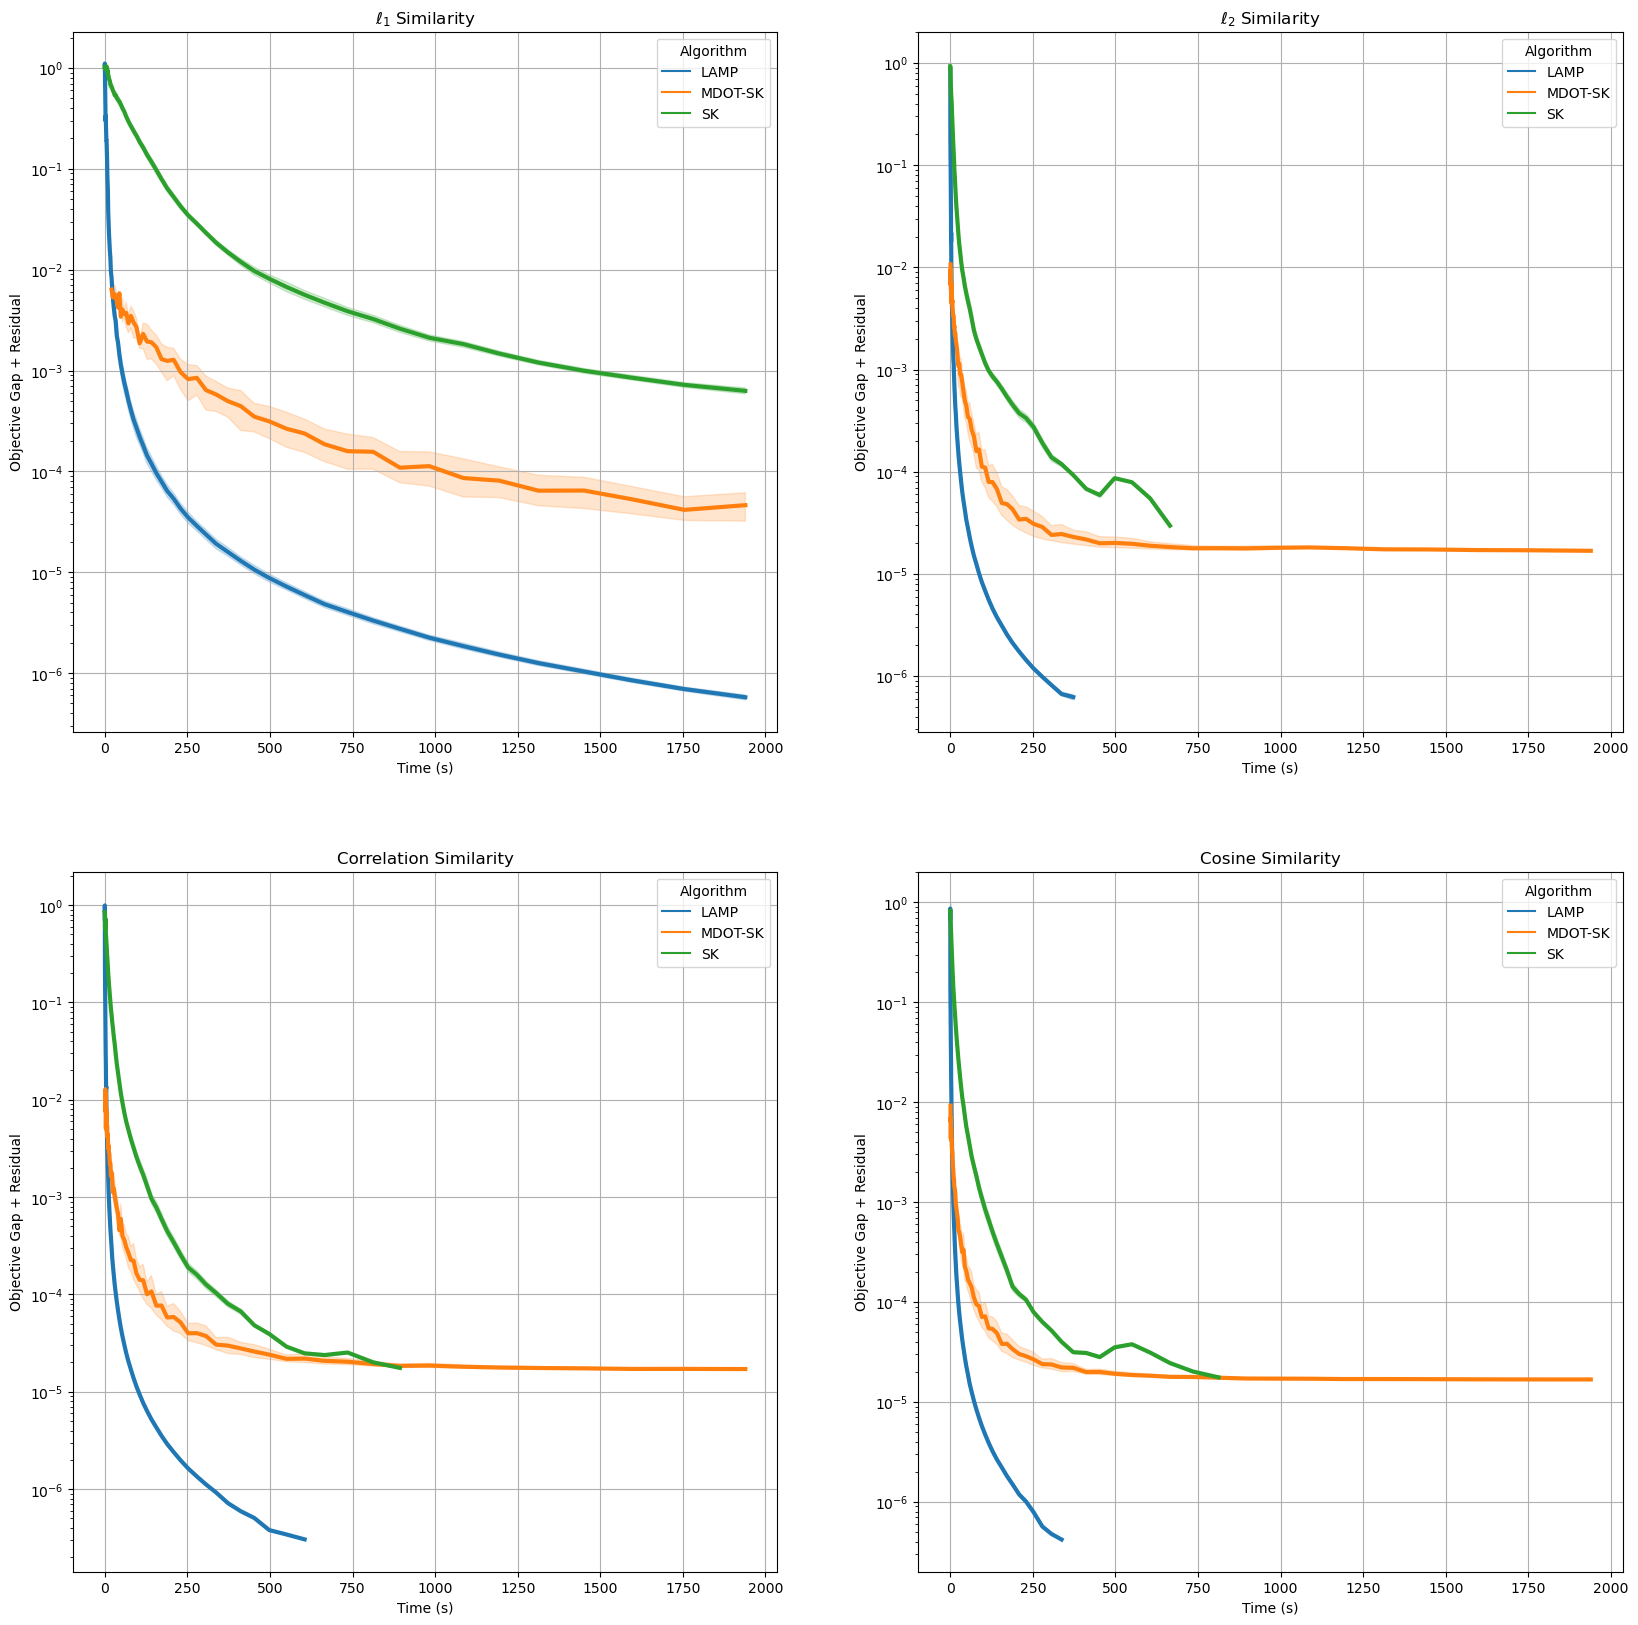

In [83]:
fig, axs = plt.subplot_mosaic([["$\\ell_1$", "$\\ell_2$"],["Correlation", "Cosine"]], figsize=(20,20))
hue_order = ["LAMP", "MDOT-SK", "SK"]

for metric in df['Metric'].unique():
    sns.lineplot(df.query(f"nfeatures==5000 and Metric == \"{metric}\" and `time(s)` < 2000"),
                 x='bintime', y='compound_obj', hue='Algorithm', ax=axs[metric], hue_order=hue_order, linewidth=3)
    axs[metric].set_yscale("log")
    # axs[metric].set_xscale("log")
    axs[metric].set_title(f"{metric} Similarity")
    axs[metric].set_ylabel(f"Objective Gap + Residual")
    axs[metric].set_xlabel(f"Time (s)")
    axs[metric].grid()